In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score

In [2]:
data=pd.read_fwf("ecoli.data")

In [3]:
import sklearn
sklearn.__version__

'1.0.2'

In [1]:
data

NameError: name 'data' is not defined

In [5]:
data.columns=["que","mcg","gvh","lip","chg","aac","alm1","alm2","Class"]
data

,que,mcg,gvh,lip,chg,aac,alm1,alm2,Class
0,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
1,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
2,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
3,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp
4,ALKH_ECOLI,0.67,0.39,0.48,0.5,0.36,0.38,0.46,cp
...,...,...,...,...,...,...,...,...,...
321,TREA_ECOLI,0.74,0.56,0.48,0.5,0.47,0.68,0.30,pp
322,UGPB_ECOLI,0.71,0.57,0.48,0.5,0.48,0.35,0.32,pp
323,USHA_ECOLI,0.61,0.60,0.48,0.5,0.44,0.39,0.38,pp
324,XYLF_ECOLI,0.59,0.61,0.48,0.5,0.42,0.42,0.37,pp


In [6]:
data.drop('que', inplace=True, axis=1)

In [7]:
#data

In [8]:
data.Class = pd.factorize(data.Class)[0] + 1

In [9]:
gb=data.groupby("Class")

In [10]:
for Class, Class_df in gb:
    print(Class)
    print(Class_df)

1
      mcg   gvh   lip  chg   aac  alm1  alm2  Class
0    0.07  0.40  0.48  0.5  0.54  0.35  0.44      1
1    0.56  0.40  0.48  0.5  0.49  0.37  0.46      1
2    0.59  0.49  0.48  0.5  0.52  0.45  0.36      1
3    0.23  0.32  0.48  0.5  0.55  0.25  0.35      1
4    0.67  0.39  0.48  0.5  0.36  0.38  0.46      1
..    ...   ...   ...  ...   ...   ...   ...    ...
137  0.40  0.41  0.48  0.5  0.55  0.22  0.33      1
138  0.22  0.34  0.48  0.5  0.42  0.29  0.39      1
139  0.44  0.35  0.48  0.5  0.44  0.52  0.59      1
140  0.27  0.42  0.48  0.5  0.37  0.38  0.43      1
141  0.16  0.43  0.48  0.5  0.54  0.27  0.37      1

[142 rows x 8 columns]
2
      mcg   gvh   lip  chg   aac  alm1  alm2  Class
142  0.06  0.61  0.48  0.5  0.49  0.92  0.37      2
143  0.44  0.52  0.48  0.5  0.43  0.47  0.54      2
144  0.63  0.47  0.48  0.5  0.51  0.82  0.84      2
145  0.23  0.48  0.48  0.5  0.59  0.88  0.89      2
146  0.34  0.49  0.48  0.5  0.58  0.85  0.80      2
..    ...   ...   ...  ...   ...   .

In [11]:
gb.get_group(1)

,mcg,gvh,lip,chg,aac,alm1,alm2,Class
0,0.07,0.40,0.48,0.5,0.54,0.35,0.44,1
1,0.56,0.40,0.48,0.5,0.49,0.37,0.46,1
2,0.59,0.49,0.48,0.5,0.52,0.45,0.36,1
3,0.23,0.32,0.48,0.5,0.55,0.25,0.35,1
4,0.67,0.39,0.48,0.5,0.36,0.38,0.46,1
...,...,...,...,...,...,...,...,...
137,0.40,0.41,0.48,0.5,0.55,0.22,0.33,1
138,0.22,0.34,0.48,0.5,0.42,0.29,0.39,1
139,0.44,0.35,0.48,0.5,0.44,0.52,0.59,1
140,0.27,0.42,0.48,0.5,0.37,0.38,0.43,1


In [12]:
class_samples=gb.get_group(1).sample(n=15)
#    print(class_samples)

In [13]:
print(type(class_samples))

<class 'pandas.core.frame.DataFrame'>


In [14]:
mean_sum=class_samples["mcg"].mean() + class_samples["gvh"].mean() + class_samples["lip"].mean() + class_samples["chg"].mean() + class_samples["aac"].mean() + class_samples["alm1"].mean() + class_samples["alm2"].mean() 

In [15]:
column_length=len(data.columns) -1

In [16]:
similar_val_1=mean_sum/column_length
print(similar_val_1)

0.39780952380952384


In [17]:
class_2_samples=gb.get_group(2).sample(n=15)
#    print(class_2_samples)

In [18]:
mean_sum_2=class_2_samples["mcg"].mean() + class_2_samples["gvh"].mean() + class_2_samples["lip"].mean() + class_2_samples["chg"].mean() + class_2_samples["aac"].mean() + class_2_samples["alm1"].mean() + class_2_samples["alm2"].mean()

In [19]:
similar_val_2=mean_sum_2/column_length
print(similar_val_2)

0.5748571428571428


In [20]:
class_3_samples=gb.get_group(3).sample(n=15)
#    print(class_3_samples)

In [21]:
mean_sum_3=class_3_samples["mcg"].mean() + class_3_samples["gvh"].mean() + class_3_samples["lip"].mean() + class_3_samples["chg"].mean() + class_3_samples["aac"].mean() + class_3_samples["alm1"].mean() + class_3_samples["alm2"].mean() 

In [22]:
similar_val_3=mean_sum_3/column_length
print(similar_val_3)

0.607904761904762


In [23]:
class_4_samples=gb.get_group(4).sample(n=15)

In [24]:
mean_sum_4=class_4_samples["mcg"].mean() + class_4_samples["gvh"].mean() + class_4_samples["lip"].mean() + class_4_samples["chg"].mean() + class_4_samples["aac"].mean() + class_4_samples["alm1"].mean() + class_4_samples["alm2"].mean() 

In [25]:
similar_val_4=mean_sum_4/column_length
print(similar_val_4)

0.5555238095238096


In [26]:
class_5_samples=gb.get_group(5).sample(n=15)

In [27]:
mean_sum_5=class_5_samples["mcg"].mean() + class_5_samples["gvh"].mean() + class_5_samples["lip"].mean() + class_5_samples["chg"].mean() + class_5_samples["aac"].mean() + class_5_samples["alm1"].mean() + class_5_samples["alm2"].mean()

In [28]:
similar_val_5=mean_sum_5/column_length
print(similar_val_5)

0.5232380952380952


In [29]:
sim_23=abs(similar_val_3 - similar_val_2)
sim_23=sim_23/1000
sim_23=1 - sim_23

sim_24=abs(similar_val_2 - similar_val_4)
sim_24=sim_24/1000
sim_24=1 - sim_24

sim_25=abs(similar_val_2 - similar_val_5)
sim_25=sim_25/1000
sim_25=1 - sim_25

sim_12=abs(similar_val_1 - similar_val_2)
sim_12=sim_12/1000
sim_12=1 - sim_12

sim_13=abs(similar_val_3 - similar_val_1)
sim_13=sim_13/1000
sim_13=1 - sim_13

sim_14=abs(similar_val_1 - similar_val_4)
sim_14=sim_12/1000
sim_14=1 - sim_14

sim_15=abs(similar_val_1 - similar_val_5)
sim_15=sim_13/1000
sim_15=1 - sim_15

sim_34=abs(similar_val_3 - similar_val_4)
sim_34=sim_34/1000
sim_34=1 - sim_34

sim_35=abs(similar_val_3 - similar_val_5)
sim_35=sim_35/1000
sim_35=1 - sim_35

sim_45=abs(similar_val_4 - similar_val_5)
sim_45=sim_45/1000
sim_45=1 - sim_45




print("Similarity between 1 and 2: ", sim_12)
print("Similarity between 1 and 3: ", sim_13)
print("Similarity between 1 and 4: ", sim_14)
print("Similarity between 1 and 5: ", sim_15)

print("Similarity between 2 and 3: ", sim_23)
print("Similarity between 2 and 4: ", sim_24)
print("Similarity between 2 and 5: ", sim_25)

print("Similarity between 3 and 4: ", sim_34)
print("Similarity between 3 and 5: ", sim_35)

print("Similarity between 4 and 5: ", sim_45)

Similarity between 1 and 2:  0.9998229523809524
Similarity between 1 and 3:  0.9997899047619048
Similarity between 1 and 4:  0.999000177047619
Similarity between 1 and 5:  0.9990002100952381
Similarity between 2 and 3:  0.9999669523809523
Similarity between 2 and 4:  0.9999806666666666
Similarity between 2 and 5:  0.9999483809523809
Similarity between 3 and 4:  0.9999476190476191
Similarity between 3 and 5:  0.9999153333333334
Similarity between 4 and 5:  0.9999677142857143


In [30]:
gb.size()

Class
1    142
2     77
3     35
4     20
5     52
dtype: int64

In [31]:
m=math.ceil((142+20)/2)

In [32]:
print(m)

81


In [33]:
len(gb)

5

In [34]:
neigh = KNeighborsClassifier(n_neighbors=5)

In [35]:
#neigh.fit(X_train, Y_train)
neigh.fit(data, data.Class)

KNeighborsClassifier()

In [36]:
result=neigh.kneighbors(data, return_distance=True)

In [37]:
print(type(result))

<class 'tuple'>


In [38]:
print(result)

(array([[0.        , 0.12328828, 0.14247807, 0.16431677, 0.16643317],
       [0.        , 0.07      , 0.08944272, 0.11958261, 0.13892444],
       [0.        , 0.12688578, 0.16217275, 0.16462078, 0.18165902],
       ...,
       [0.        , 0.04358899, 0.09380832, 0.09486833, 0.11401754],
       [0.        , 0.04358899, 0.07      , 0.07615773, 0.11532563],
       [0.        , 0.16401219, 0.17578396, 0.19235384, 0.19416488]]), array([[  0, 121, 141,  44, 133],
       [  1, 123,  43, 107,  86],
       [  2,  43,   1,  12,  98],
       ...,
       [323, 324, 302, 282, 317],
       [324, 323, 302, 284, 317],
       [325, 285, 289, 286, 298]], dtype=int64))


In [39]:
arr1=result[0]

In [40]:
print(type(arr1))

<class 'numpy.ndarray'>


In [41]:
print(arr1.ndim)

2


In [42]:
arr2=result[1]

In [43]:
print(type(arr2))

<class 'numpy.ndarray'>


In [44]:
print(arr1.ndim)

2


In [45]:
print(arr2)

[[  0 121 141  44 133]
 [  1 123  43 107  86]
 [  2  43   1  12  98]
 ...
 [323 324 302 282 317]
 [324 323 302 284 317]
 [325 285 289 286 298]]


In [46]:
print(arr1)

[[0.         0.12328828 0.14247807 0.16431677 0.16643317]
 [0.         0.07       0.08944272 0.11958261 0.13892444]
 [0.         0.12688578 0.16217275 0.16462078 0.18165902]
 ...
 [0.         0.04358899 0.09380832 0.09486833 0.11401754]
 [0.         0.04358899 0.07       0.07615773 0.11532563]
 [0.         0.16401219 0.17578396 0.19235384 0.19416488]]


In [47]:
#print(arr1)

In [48]:
print(arr1.size)

1630


In [49]:
#tHIS LINE TAKES THE SUMMATION OF A THE DISTANCE BETWEEN THE INSTANCE AND IT'S NEIGHBORS
addVal=[]
s=1
for i in arr1:
    _sum=int(i[0] + i[1] + i[2] + i[3] + i[4])
    addVal.append(_sum)
    print(i ," ", _sum, " ") 
    s=s+1

[0.         0.12328828 0.14247807 0.16431677 0.16643317]   0  
[0.         0.07       0.08944272 0.11958261 0.13892444]   0  
[0.         0.12688578 0.16217275 0.16462078 0.18165902]   0  
[0.         0.07       0.10535654 0.11090537 0.11401754]   0  
[0.         0.15066519 0.15811388 0.16309506 0.16431677]   0  
[0.         0.05385165 0.09539392 0.10535654 0.1086278 ]   0  
[0.         0.07       0.07       0.08717798 0.09055385]   0  
[0.         0.09273618 0.10723805 0.13266499 0.14422205]   0  
[0.         0.05567764 0.06855655 0.1034408  0.11445523]   0  
[0.         0.10908712 0.12569805 0.14387495 0.14696938]   0  
[0.         0.07211103 0.09327379 0.1034408  0.11090537]   0  
[0.         0.04690416 0.07416198 0.07937254 0.10954451]   0  
[0.         0.09380832 0.09539392 0.10440307 0.11090537]   0  
[0.         0.07211103 0.0969536  0.11269428 0.11532563]   0  
[0.         0.05385165 0.08774964 0.09643651 0.10723805]   0  
[0.         0.06164414 0.06324555 0.06855655 0.08602325

[0.         0.27694765 0.27982137 0.31016125 0.35270384]   1  
[0.         0.10535654 0.11874342 0.12083046 0.12247449]   0  
[0.         0.09327379 0.1183216  0.19235384 0.19364917]   0  
[0.         0.12649111 0.14071247 0.14798649 0.17720045]   0  
[0.         0.07745967 0.0781025  0.07874008 0.08185353]   0  
[0.         0.11445523 0.15165751 0.15716234 0.16552945]   0  
[0.         0.13266499 0.15165751 0.15231546 0.16792856]   0  
[0.         0.19672316 0.1977372  0.20663978 0.27073973]   0  
[0.         0.12845233 0.13490738 0.14071247 0.16583124]   0  
[0.         0.09110434 0.09643651 0.10099505 0.11135529]   0  
[0.         0.1174734  0.21023796 0.21118712 0.22090722]   0  
[0.         0.12767145 0.13638182 0.13820275 0.15620499]   0  
[0.         0.05385165 0.09486833 0.10488088 0.10954451]   0  
[0.         0.09643651 0.10148892 0.10488088 0.12247449]   0  
[0.         0.09273618 0.10440307 0.10630146 0.12727922]   0  
[0.         0.0781025  0.08888194 0.09486833 0.1118034 

In [50]:
print(len(addVal))

326


In [51]:
#THE VALUE FOR THE SUMMATION OF ALL THE DISTANCES
print(addVal)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]


In [52]:
arr3=np.array(addVal)

In [53]:
print(type(arr3))

<class 'numpy.ndarray'>


In [54]:
print(arr3.size)

326


In [55]:
print(arr3)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 2 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0]


In [56]:
g=1
for i in addVal:
    print(g ," ", i) 
    g=g+1

1   0
2   0
3   0
4   0
5   0
6   0
7   0
8   0
9   0
10   0
11   0
12   0
13   0
14   0
15   0
16   0
17   0
18   0
19   0
20   1
21   0
22   0
23   0
24   0
25   0
26   0
27   0
28   0
29   0
30   0
31   0
32   0
33   0
34   0
35   0
36   0
37   0
38   0
39   0
40   0
41   0
42   0
43   0
44   0
45   0
46   0
47   0
48   0
49   0
50   0
51   0
52   0
53   0
54   0
55   0
56   0
57   0
58   0
59   0
60   0
61   0
62   0
63   0
64   0
65   0
66   0
67   0
68   0
69   0
70   0
71   0
72   0
73   0
74   0
75   0
76   0
77   0
78   0
79   0
80   0
81   0
82   0
83   0
84   0
85   0
86   0
87   0
88   0
89   0
90   0
91   0
92   0
93   0
94   0
95   1
96   0
97   0
98   0
99   0
100   0
101   0
102   0
103   0
104   0
105   0
106   0
107   0
108   0
109   0
110   0
111   0
112   0
113   0
114   0
115   0
116   0
117   0
118   0
119   0
120   0
121   0
122   0
123   0
124   0
125   0
126   0
127   0
128   0
129   0
130   0
131   0
132   0
133   0
134   0
135   0
136   0
137   0
138   0
139 

In [57]:
newarr = arr3.reshape(326, 1)

In [58]:
print(newarr.ndim)

2


In [59]:
new_arr2=np.append(arr2, newarr, axis=1)

In [60]:
print(type(new_arr2))

<class 'numpy.ndarray'>


In [61]:
#FORM AN ARRAY THAT INCLUDES THE INDICE OF NEIGHBORS AND THE DISTANCE AS THE LAST INDICE
print(new_arr2)

[[  0 121 141  44 133   0]
 [  1 123  43 107  86   0]
 [  2  43   1  12  98   0]
 ...
 [323 324 302 282 317   0]
 [324 323 302 284 317   0]
 [325 285 289 286 298   0]]


In [62]:
print(new_arr2[0])

[  0 121 141  44 133   0]


In [63]:
arr2

array([[  0, 121, 141,  44, 133],
       [  1, 123,  43, 107,  86],
       [  2,  43,   1,  12,  98],
       ...,
       [323, 324, 302, 282, 317],
       [324, 323, 302, 284, 317],
       [325, 285, 289, 286, 298]], dtype=int64)

In [64]:
print(new_arr2[0][1],  new_arr2[0][2],  new_arr2[0][3], new_arr2[0][4],new_arr2[0][5])

121 141 44 133 0


In [65]:
data

,mcg,gvh,lip,chg,aac,alm1,alm2,Class
0,0.07,0.40,0.48,0.5,0.54,0.35,0.44,1
1,0.56,0.40,0.48,0.5,0.49,0.37,0.46,1
2,0.59,0.49,0.48,0.5,0.52,0.45,0.36,1
3,0.23,0.32,0.48,0.5,0.55,0.25,0.35,1
4,0.67,0.39,0.48,0.5,0.36,0.38,0.46,1
...,...,...,...,...,...,...,...,...
321,0.74,0.56,0.48,0.5,0.47,0.68,0.30,5
322,0.71,0.57,0.48,0.5,0.48,0.35,0.32,5
323,0.61,0.60,0.48,0.5,0.44,0.39,0.38,5
324,0.59,0.61,0.48,0.5,0.42,0.42,0.37,5


In [66]:
# Creating and populating a dictionary with the 'key' as key and class value as value
new_dist={}
for i, v in data.Class.iteritems():
    new_dist[i]=v

In [67]:
#print(new_dist)

In [68]:
# Creating and populating a dictionary with the 's=0 to end' as key and class value as value
new_dist2={}
s=0
for i, v in data.Class.iteritems():
    new_dist2[s]=v
    s=s+1

In [69]:
#print(new_dist2)

In [70]:
# Creating and populating a dictionary with the 's=0 to end' as key and 'index value' as value
new_dist3={}
s=0
for i, v in data.Class.iteritems():
    new_dist3[s]=i
    s=s+1

In [71]:
#print(new_dist3)

In [72]:
#print(new_dist[204])

In [73]:
#new_dist3

<!-- Populating a dictionary  -->

In [74]:
    neigh_count=[]
    s=0
    for i, v in new_dist2.items():
        c1=0
        c2=0
        c3=0
        c4=0
        c5=0
        class_example=0
        
        if int(v) == 1:
            c1=c1+1
        elif int(v) == 2:
            c2=c2+1
        elif int(v) == 3:
            c3=c3+1
        elif int(v) == 4:
            c4=c4+1
        else:
            c5=c5+1
            
        for x in range(1,5):
            if new_dist2[new_arr2[i][x]]==1:
                c1=c1+1
            elif new_dist2[new_arr2[i][x]]==2:
                c2=c2+1
            elif new_dist2[new_arr2[i][x]]==3:
                c3=c3+1
            elif new_dist2[new_arr2[i][x]]==4:
                c4=c4+1
            else:
                c5=c5+1
            if int(v) == 1:
                safe_level=(1 * c1 + sim_12 * c2 + sim_13 * c3 + sim_14 * c4 + sim_15 * c5)/5
                class_example=1
                safe_level=round(safe_level,2)
            elif int(v) == 2:
                safe_level=(sim_12 * c1 + 1 * c2 + sim_23 * c3+ sim_24 * c3 + sim_25 * c5)/5
                class_example=2
                safe_level=round(safe_level,2)
            elif int(v) == 3:
                safe_level=(sim_13 * c1 + sim_23 * c2 + 1 * c3  + sim_34 * c4 + sim_35 * c5)/5
                class_example=3
                safe_level=round(safe_level,2)
            elif int(v) == 4:
                safe_level=(sim_14 * c1 + sim_24 * c2 + sim_34 * c3 + 1 * c4 + sim_35 * c5)/5
                class_example=4
                safe_level=round(safe_level,2)
            else:
                safe_level=(sim_15 * c1 + sim_25 * c2   + sim_35 * c3 + sim_45 * c4 + 1 * c5)/5
                class_example=5
                safe_level=round(safe_level,2)
                
        neigh_count.append([i,new_dist3[i],class_example,c1,c2,c3,c4,c5,safe_level,new_arr2[i][5]])
        
        
        #print(i," ",new_dist3[i]," ",class_example," ",c1," ",c2," ",c3," ",safe_level," ",new_arr2[i][5])
        #print(i," ",new_dist3[i]," ",c1," ",c2," ",c3," ",new_arr2[i][5])
    #real_new=new_dist3[i]," ",new_arr2[i][1]," ",new_arr2[i][2]," ",new_arr2[i][3]," ",new_arr2[i][4]," ",new_arr2[i][5]
    
    #print(i," ",real_new)

In [75]:
print(neigh_count)

[[0, 0, 1, 5, 0, 0, 0, 0, 1.0, 0], [1, 1, 1, 5, 0, 0, 0, 0, 1.0, 0], [2, 2, 1, 5, 0, 0, 0, 0, 1.0, 0], [3, 3, 1, 5, 0, 0, 0, 0, 1.0, 0], [4, 4, 1, 5, 0, 0, 0, 0, 1.0, 0], [5, 5, 1, 5, 0, 0, 0, 0, 1.0, 0], [6, 6, 1, 5, 0, 0, 0, 0, 1.0, 0], [7, 7, 1, 5, 0, 0, 0, 0, 1.0, 0], [8, 8, 1, 5, 0, 0, 0, 0, 1.0, 0], [9, 9, 1, 5, 0, 0, 0, 0, 1.0, 0], [10, 10, 1, 5, 0, 0, 0, 0, 1.0, 0], [11, 11, 1, 5, 0, 0, 0, 0, 1.0, 0], [12, 12, 1, 5, 0, 0, 0, 0, 1.0, 0], [13, 13, 1, 5, 0, 0, 0, 0, 1.0, 0], [14, 14, 1, 5, 0, 0, 0, 0, 1.0, 0], [15, 15, 1, 5, 0, 0, 0, 0, 1.0, 0], [16, 16, 1, 5, 0, 0, 0, 0, 1.0, 0], [17, 17, 1, 5, 0, 0, 0, 0, 1.0, 0], [18, 18, 1, 5, 0, 0, 0, 0, 1.0, 0], [19, 19, 1, 5, 0, 0, 0, 0, 1.0, 1], [20, 20, 1, 5, 0, 0, 0, 0, 1.0, 0], [21, 21, 1, 5, 0, 0, 0, 0, 1.0, 0], [22, 22, 1, 5, 0, 0, 0, 0, 1.0, 0], [23, 23, 1, 5, 0, 0, 0, 0, 1.0, 0], [24, 24, 1, 5, 0, 0, 0, 0, 1.0, 0], [25, 25, 1, 5, 0, 0, 0, 0, 1.0, 0], [26, 26, 1, 5, 0, 0, 0, 0, 1.0, 0], [27, 27, 1, 5, 0, 0, 0, 0, 1.0, 0], [28, 28, 1,

In [76]:
# iterating a dictionary

In [77]:
# for s in range(149):
#     print(neigh_count[s])

In [78]:
# Converting a dictionary to a dataframe

In [79]:
new_main_df = pd.DataFrame(neigh_count,columns=['s_no','real_index','Class','c_one','c_two','c_three','c_four','c_five','safe_level','distance'])

In [80]:
#print(new_main_df)

In [81]:
new_main_df.set_index("s_no", inplace=True)

In [82]:
print(new_main_df)

      real_index  Class  c_one  c_two  c_three  c_four  c_five  safe_level  \
s_no                                                                         
0              0      1      5      0        0       0       0         1.0   
1              1      1      5      0        0       0       0         1.0   
2              2      1      5      0        0       0       0         1.0   
3              3      1      5      0        0       0       0         1.0   
4              4      1      5      0        0       0       0         1.0   
...          ...    ...    ...    ...      ...     ...     ...         ...   
321          321      5      0      0        0       0       5         1.0   
322          322      5      0      0        0       0       5         1.0   
323          323      5      0      0        0       0       5         1.0   
324          324      5      0      0        0       0       5         1.0   
325          325      5      0      0        0       0       5  

In [83]:
# iterating through a dataframe, the following methods can be used .iterrows() 
# and itertuples() but itertuples is preferred because it keeps the data types and more

In [84]:
# for index, row in new_main_df.iterrows():
#     print(index, row['real_index'], row['class'], row['c_one'], row['c_two'], row['c_three'], row['safe_level'], row['distance'] )

In [85]:
for i, row in enumerate(new_main_df.itertuples(), 0):
    print(i, row.real_index)
    

0 0
1 1
2 2
3 3
4 4
5 5
6 6
7 7
8 8
9 9
10 10
11 11
12 12
13 13
14 14
15 15
16 16
17 17
18 18
19 19
20 20
21 21
22 22
23 23
24 24
25 25
26 26
27 27
28 28
29 29
30 30
31 31
32 32
33 33
34 34
35 35
36 36
37 37
38 38
39 39
40 40
41 41
42 42
43 43
44 44
45 45
46 46
47 47
48 48
49 49
50 50
51 51
52 52
53 53
54 54
55 55
56 56
57 57
58 58
59 59
60 60
61 61
62 62
63 63
64 64
65 65
66 66
67 67
68 68
69 69
70 70
71 71
72 72
73 73
74 74
75 75
76 76
77 77
78 78
79 79
80 80
81 81
82 82
83 83
84 84
85 85
86 86
87 87
88 88
89 89
90 90
91 91
92 92
93 93
94 94
95 95
96 96
97 97
98 98
99 99
100 100
101 101
102 102
103 103
104 104
105 105
106 106
107 107
108 108
109 109
110 110
111 111
112 112
113 113
114 114
115 115
116 116
117 117
118 118
119 119
120 120
121 121
122 122
123 123
124 124
125 125
126 126
127 127
128 128
129 129
130 130
131 131
132 132
133 133
134 134
135 135
136 136
137 137
138 138
139 139
140 140
141 141
142 142
143 143
144 144
145 145
146 146
147 147
148 148
149 149
150 150
151 151
152 

In [86]:
new_classes=new_main_df.groupby("Class")

In [87]:
new_classes.size()

Class
1    142
2     77
3     35
4     20
5     52
dtype: int64

In [88]:
new_class_1=new_classes.get_group(1)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_1.itertuples(index=True), 0):
    if(row.c_one==5  or row.c_one==4):
        safe_exam=safe_exam + 1
    elif(row.c_one==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_one==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

142 0 0 0


In [89]:
new_class_2=new_classes.get_group(2)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_2.itertuples(index=True), 0):
    if(row.c_two==5  or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

77 0 0 0


In [90]:
new_class_3=new_classes.get_group(3)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_3.itertuples(index=True), 0):
    if(row.c_three==5  or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_three==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_three==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

35 0 0 0


In [91]:
new_class_4=new_classes.get_group(4)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_4.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

0 0 0 20


In [92]:
new_class_5=new_classes.get_group(5)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_5.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

0 0 0 52


In [93]:
# for row in new_main_df.itertuples():
#     print(getattr(row, 'real_index'), getattr(row, 'c_one'))

In [94]:
new_gb=new_main_df.groupby("Class")

In [95]:
new_1=new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [96]:
gb_1=gb.get_group(1)

In [97]:
gb_2=gb.get_group(2)

In [98]:
gb_3=gb.get_group(3)

In [99]:
gb_4=gb.get_group(4)

In [100]:
gb_5=gb.get_group(5)

In [101]:
#new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [102]:
new_2=new_gb.get_group(2).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [103]:
new_3=new_gb.get_group(3).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [104]:
new_4=new_gb.get_group(4).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [105]:
new_5=new_gb.get_group(5).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [106]:
#for dropping some index with less simlar neigbour
#new_3.drop(new_3[new_3['c_three'] < 4].index, inplace=True)

In [107]:
minor_c_1=new_1.sample(n=m, replace='False')

In [108]:
new_gb

In [109]:
gb

In [110]:
minor_c_2=new_2.sample(n=m, replace='True')

In [111]:
minor_c_3=new_3.sample(n=m, replace='True')

In [112]:
minor_c_4=new_4.sample(n=m, replace='True')

In [113]:
minor_c_5=new_5.sample(n=m, replace='False')

In [114]:
maj_c_filtered=[]
for i, row in enumerate(minor_c_1.itertuples(index=True), 0):
    a=gb_1.at[row.real_index, 'Class']
    b=gb_1.at[row.real_index, 'mcg']
    c=gb_1.at[row.real_index, 'gvh']
    d=gb_1.at[row.real_index, 'lip']
    e=gb_1.at[row.real_index, 'chg']
    f=gb_1.at[row.real_index, 'aac']
    g=gb_1.at[row.real_index, 'alm1']
    h=gb_1.at[row.real_index, 'alm2']
    maj_c_filtered.append([a,b,c,d,e,f,g,h])

In [115]:
#for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    #print(i, row.real_index)

In [116]:
min_c_2_filtered=[]
for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    a=gb_2.at[row.real_index, 'Class']
    b=gb_2.at[row.real_index, 'mcg']
    c=gb_2.at[row.real_index, 'gvh']
    d=gb_2.at[row.real_index, 'lip']
    e=gb_2.at[row.real_index, 'chg']
    f=gb_2.at[row.real_index, 'aac']
    g=gb_2.at[row.real_index, 'alm1']
    h=gb_2.at[row.real_index, 'alm2']
    min_c_2_filtered.append([a,b,c,d,e,f,g,h])

In [117]:
min_c_3_filtered=[]
for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    a=gb_3.at[row.real_index, 'Class']
    b=gb_3.at[row.real_index, 'mcg']
    c=gb_3.at[row.real_index, 'gvh']
    d=gb_3.at[row.real_index, 'lip']
    e=gb_3.at[row.real_index, 'chg']
    f=gb_3.at[row.real_index, 'aac']
    g=gb_3.at[row.real_index, 'alm1']
    h=gb_3.at[row.real_index, 'alm2']
    min_c_3_filtered.append([a,b,c,d,e,f,g,h])

In [118]:
#print(min_c_3_filtered)

In [119]:
min_c_4_filtered=[]
for i, row in enumerate(minor_c_4.itertuples(index=True), 0):
    a=gb_4.at[row.real_index, 'Class']
    b=gb_4.at[row.real_index, 'mcg']
    c=gb_4.at[row.real_index, 'gvh']
    d=gb_4.at[row.real_index, 'lip']
    e=gb_4.at[row.real_index, 'chg']
    f=gb_4.at[row.real_index, 'aac']
    g=gb_4.at[row.real_index, 'alm1']
    h=gb_4.at[row.real_index, 'alm2']
    min_c_4_filtered.append([a,b,c,d,e,f,g,h])

In [120]:
min_c_5_filtered=[]
for i, row in enumerate(minor_c_5.itertuples(index=True), 0):
    a=gb_5.at[row.real_index, 'Class']
    b=gb_5.at[row.real_index, 'mcg']
    c=gb_5.at[row.real_index, 'gvh']
    d=gb_5.at[row.real_index, 'lip']
    e=gb_5.at[row.real_index, 'chg']
    f=gb_5.at[row.real_index, 'aac']
    g=gb_5.at[row.real_index, 'alm1']
    h=gb_5.at[row.real_index, 'alm2']
    min_c_5_filtered.append([a,b,c,d,e,f,g,h])

In [121]:
new_maj_c_filtered = pd.DataFrame(maj_c_filtered,columns=['Class','mcg','gvh','lip','chg','aac','alm1','alm2'])

In [122]:
print(new_maj_c_filtered)

    Class   mcg   gvh   lip  chg   aac  alm1  alm2
0       1  0.47  0.47  0.48  0.5  0.22  0.16  0.26
1       1  0.25  0.37  0.48  0.5  0.43  0.26  0.36
2       1  0.22  0.43  0.48  0.5  0.48  0.16  0.28
3       1  0.29  0.28  0.48  0.5  0.44  0.23  0.34
4       1  0.40  0.45  0.48  0.5  0.38  0.22  0.00
..    ...   ...   ...   ...  ...   ...   ...   ...
76      1  0.32  0.33  0.48  0.5  0.60  0.06  0.20
77      1  0.34  0.46  0.48  0.5  0.52  0.35  0.44
78      1  0.34  0.33  0.48  0.5  0.38  0.35  0.44
79      1  0.47  0.47  0.48  0.5  0.22  0.16  0.26
80      1  0.23  0.40  0.48  0.5  0.39  0.28  0.38

[81 rows x 8 columns]


In [123]:
new_min_c_2_filtered = pd.DataFrame(min_c_2_filtered, columns=['Class','mcg','gvh','lip','chg','aac','alm1','alm2'])
new_min_c_3_filtered = pd.DataFrame(min_c_3_filtered, columns=['Class','mcg','gvh','lip','chg','aac','alm1','alm2'])
new_min_c_4_filtered = pd.DataFrame(min_c_4_filtered, columns=['Class','mcg','gvh','lip','chg','aac','alm1','alm2'])
new_min_c_5_filtered = pd.DataFrame(min_c_5_filtered, columns=['Class','mcg','gvh','lip','chg','aac','alm1','alm2'])

In [124]:
print(new_min_c_5_filtered)

    Class   mcg   gvh   lip  chg   aac  alm1  alm2
0       5  0.74  0.82  0.48  0.5  0.49  0.49  0.41
1       5  0.74  0.56  0.48  0.5  0.47  0.68  0.30
2       5  0.56  0.54  0.48  0.5  0.43  0.37  0.30
3       5  0.64  0.72  0.48  0.5  0.49  0.42  0.19
4       5  0.66  0.71  0.48  0.5  0.41  0.50  0.35
..    ...   ...   ...   ...  ...   ...   ...   ...
76      5  0.74  0.56  0.48  0.5  0.47  0.68  0.30
77      5  0.73  0.78  0.48  0.5  0.58  0.51  0.31
78      5  0.68  0.67  0.48  0.5  0.49  0.40  0.34
79      5  0.71  0.57  0.48  0.5  0.48  0.35  0.32
80      5  0.61  0.60  0.48  0.5  0.44  0.39  0.38

[81 rows x 8 columns]


In [125]:
result = new_maj_c_filtered.append([new_min_c_2_filtered, new_min_c_3_filtered, new_min_c_4_filtered, new_min_c_5_filtered], ignore_index='True')

In [126]:
print(result)

     Class   mcg   gvh   lip  chg   aac  alm1  alm2
0        1  0.47  0.47  0.48  0.5  0.22  0.16  0.26
1        1  0.25  0.37  0.48  0.5  0.43  0.26  0.36
2        1  0.22  0.43  0.48  0.5  0.48  0.16  0.28
3        1  0.29  0.28  0.48  0.5  0.44  0.23  0.34
4        1  0.40  0.45  0.48  0.5  0.38  0.22  0.00
..     ...   ...   ...   ...  ...   ...   ...   ...
400      5  0.74  0.56  0.48  0.5  0.47  0.68  0.30
401      5  0.73  0.78  0.48  0.5  0.58  0.51  0.31
402      5  0.68  0.67  0.48  0.5  0.49  0.40  0.34
403      5  0.71  0.57  0.48  0.5  0.48  0.35  0.32
404      5  0.61  0.60  0.48  0.5  0.44  0.39  0.38

[405 rows x 8 columns]


In [127]:
result.to_csv("balanced_ecoli.csv")

In [128]:
result=result.sample(frac=1).reset_index(drop=True)

In [129]:
result.to_csv("balanced_ecoli_rand.csv")

In [130]:
X_train, X_test, Y_train, Y_test = train_test_split(result, result.Class, train_size=.7)

In [131]:
categories=result.groupby("Class")

In [132]:
w=categories.size()

In [133]:
print(w)

Class
1    81
2    81
3    81
4    81
5    81
dtype: int64


In [134]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
knn = KNeighborsClassifier(n_neighbors=5)

In [135]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [136]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [137]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [138]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))


Accuracy for SVM Test Data:                         1.0
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         1.0


In [139]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [140]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            1.0
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            1.0


In [141]:
cm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [142]:
cm_model_test

array([[29,  0,  0,  0,  0],
       [ 0, 22,  0,  0,  0],
       [ 0,  0, 26,  0,  0],
       [ 0,  0,  0, 18,  0],
       [ 0,  0,  0,  0, 27]], dtype=int64)

In [143]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=model.classes_)

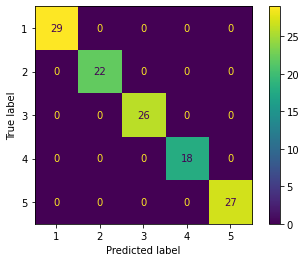

In [144]:
disp_model.plot() 

In [145]:
cm_clf_test=confusion_matrix(Y_test, clf_X_test_pred)

In [146]:
cm_clf_test

array([[29,  0,  0,  0,  0],
       [ 0, 22,  0,  0,  0],
       [ 0,  0, 26,  0,  0],
       [ 0,  0,  0, 18,  0],
       [ 0,  0,  0,  0, 27]], dtype=int64)

In [147]:
disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test, display_labels=model.classes_)

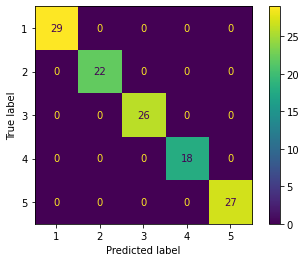

In [148]:
disp_clf.plot() 

In [149]:
cm_knn_test=confusion_matrix(Y_test, knn_X_test_pred)

In [150]:
cm_knn_test

array([[29,  0,  0,  0,  0],
       [ 0, 22,  0,  0,  0],
       [ 0,  0, 26,  0,  0],
       [ 0,  0,  0, 18,  0],
       [ 0,  0,  0,  0, 27]], dtype=int64)

In [151]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=model.classes_)

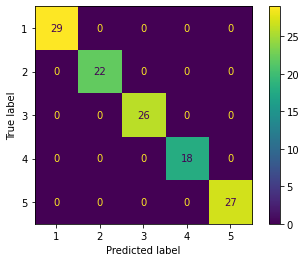

In [152]:
disp_knn.plot()

In [153]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        29
           2      1.000     1.000     1.000        22
           3      1.000     1.000     1.000        26
           4      1.000     1.000     1.000        18
           5      1.000     1.000     1.000        27

    accuracy                          1.000       122
   macro avg      1.000     1.000     1.000       122
weighted avg      1.000     1.000     1.000       122



In [154]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        29
           2      1.000     1.000     1.000        22
           3      1.000     1.000     1.000        26
           4      1.000     1.000     1.000        18
           5      1.000     1.000     1.000        27

    accuracy                          1.000       122
   macro avg      1.000     1.000     1.000       122
weighted avg      1.000     1.000     1.000       122



In [155]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        29
           2      1.000     1.000     1.000        22
           3      1.000     1.000     1.000        26
           4      1.000     1.000     1.000        18
           5      1.000     1.000     1.000        27

    accuracy                          1.000       122
   macro avg      1.000     1.000     1.000       122
weighted avg      1.000     1.000     1.000       122



In [156]:
#model_cvp=cross_val_predict(model, X_test, Y_test, cv=3, method="predict")

In [157]:
#roc_auc_score(Y_test, model_pred_proba, multi_class='ovr')